<a href="https://colab.research.google.com/github/saraeastough/SCI1500-Sara-Eastough-public/blob/main/SCIE1500Materials/Week_6/LabFiles/Week06_Lab_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Lab — Carbon Sequestration and Integration
**SCIE1500 — Analytical Methods for Scientists (UWA)**

**Lab format:** Work in your groups. Read each section, run the code cells, and answer the written prompts.

---
**This week:** We apply integration to model cumulative carbon captured by a reforestation project.

---
## 📋 Scientific Scenario

![Carbon sequestration rate and cumulative capture over time](https://github.com/ahailu95/scie1500-content/blob/main/SCIE1500Materials/Week_6/images/W6_carbon_sequestration.svg?raw=1)

A reforestation project in the Wheatbelt plants native trees across 500 ha. The rate of carbon sequestration (tonnes CO₂ per hectare per year) declines over time as trees mature:

$$R(t) = 12 e^{-0.05t}$$

where $t$ is years since planting ($t = 0$ to $t = 40$). Carbon credits sell at **$25 per tonne**.

---
## 🎯 Group Task & Learning Objectives

| Part | Topic | Time |
|------|-------|------|
| A | Distinguish the rate R(t) from the total it accumulates, and estimate that total numerically | ~20 min |
| B | Find antiderivatives and determine the constant of integration | ~20 min |
| C | Value the carbon project over 40 years | ~20 min |
| D | Verify your antiderivative symbolically using SymPy | ~10 min |

By the end you should be able to: compute antiderivatives of exponential functions; evaluate definite integrals; interpret the constant of integration; translate carbon totals into revenue; and use SymPy (`sp.integrate()`) to integrate expressions symbolically.

In [4]:
# Run this cell first — loads libraries for today's lab
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Carbon sequestration model
def R(t):
    'Sequestration rate (t CO2/ha/yr) at year t.'
    return 12 * np.exp(-0.05 * t)

t_vals = np.arange(0, 41)
print("Year | Rate (t CO2/ha/yr)")
print("-" * 28)
for t in [0, 5, 10, 20, 40]:
    print(f"  {t:2d} |   {R(t):6.2f}")

Year | Rate (t CO2/ha/yr)
----------------------------
   0 |    12.00
   5 |     9.35
  10 |     7.28
  20 |     4.41
  40 |     1.62


---
## Part A: Rates vs Totals (~20 min)

$R(t) = 12e^{-0.05t}$ is the **instantaneous rate** — how fast carbon is captured at year $t$.

The **total** carbon captured from $t=0$ to $t=T$ is the definite integral:

$$F(T) = \int_0^T R(t)\,dt = \int_0^T 12e^{-0.05t}\,dt$$

**A.1** Plot $R(t)$ over 40 years. Describe the shape: is the rate increasing or decreasing? Why does this make biological sense?

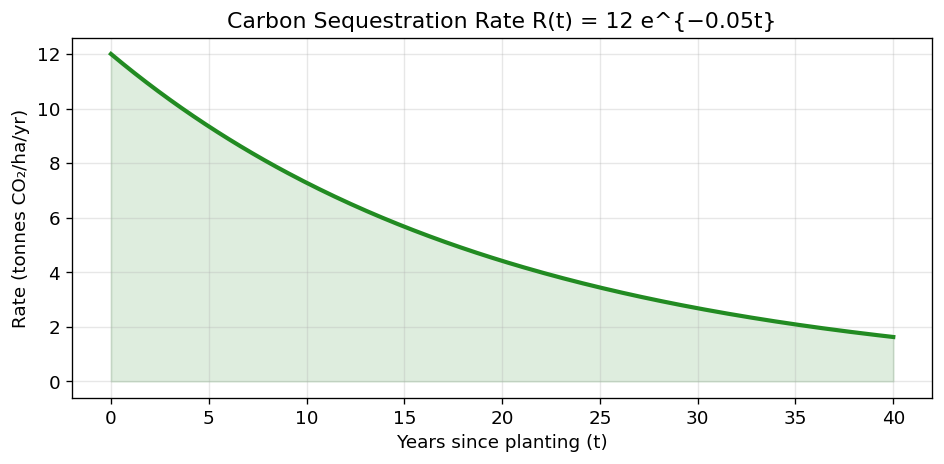

Rate at t=0 : 12.00 t CO2/ha/yr
Rate at t=20: 4.41 t CO2/ha/yr
Rate at t=40: 1.62 t CO2/ha/yr


In [5]:
# A.1 — Plot the sequestration rate
t_vals = np.linspace(0, 40, 200)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_vals, R(t_vals), "forestgreen", lw=2.5)
ax.fill_between(t_vals, R(t_vals), alpha=0.15, color="forestgreen")
ax.set_xlabel("Years since planting (t)")
ax.set_ylabel("Rate (tonnes CO₂/ha/yr)")
ax.set_title("Carbon Sequestration Rate R(t) = 12 e^{−0.05t}")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rate at t=0 : {R(0):.2f} t CO2/ha/yr")
print(f"Rate at t=20: {R(20):.2f} t CO2/ha/yr")
print(f"Rate at t=40: {R(40):.2f} t CO2/ha/yr")

**A.2** We don't have a formula for $F(t)$ yet — that comes in Part B. For now, approximate the total carbon captured in the first 5 years, $F(5) = \int_0^5 R(t)\,dt$, numerically using a Riemann sum (the trapezoidal rule).

In [6]:
# A.2 — Numerical approximation of total carbon in first 5 years
# Riemann sum (trapezoidal) for ∫₀⁵ R(t) dt
try:
    from numpy import trapezoid  # NumPy >= 2.0
except ImportError:
    from numpy import trapz as trapezoid  # NumPy < 2.0
t_fine = np.linspace(0, 5, 1000)
total_5yr = trapezoid(R(t_fine), t_fine)
print(f"Approximate total carbon (0–5 yr, per hectare): {total_5yr:.2f} tonnes CO2")
print(f"On 500 ha: {500 * total_5yr:,.0f} tonnes CO2")

Approximate total carbon (0–5 yr, per hectare): 53.09 tonnes CO2
On 500 ha: 26,544 tonnes CO2


---
## Part B: Antiderivatives (~20 min)

Recall: $\int e^{kt}\,dt = \dfrac{1}{k}e^{kt} + C$

**B.1** Find the general antiderivative $F(t)$ of $R(t) = 12e^{-0.05t}$.

$$F(t) = \int 12e^{-0.05t}\,dt = \frac{12}{-0.05}e^{-0.05t} + C = -240e^{-0.05t} + C$$

**B.2** Use the initial condition $F(0) = 0$ (no carbon captured at $t=0$) to find $C$.

$$F(0) = -240e^{0} + C = 0 \implies C = 240$$

So: $F(t) = 240(1 - e^{-0.05t})$

✏️ **Interpret $C$:** What would $F(0)$ equal if $C \neq 240$? What does the constant of integration represent in this context?

In [7]:
# B.1 — Antiderivative F(t) = 240(1 - e^{-0.05t}) per hectare
def F(t):
    'Cumulative CO2 captured (t CO2/ha) from year 0 to year t.'
    return 240 * (1 - np.exp(-0.05 * t))

# Verify: F(0) = 0
print(f"F(0) = {F(0):.4f}  (should be 0)")
print(f"F(5) = {F(5):.2f} t CO2/ha")
print(f"F(20) = {F(20):.2f} t CO2/ha")
print(f"F(40) = {F(40):.2f} t CO2/ha")

# Long-run limit
print(f"Long-run limit as t→∞: {240:.0f} t CO2/ha")

F(0) = 0.0000  (should be 0)
F(5) = 53.09 t CO2/ha
F(20) = 151.71 t CO2/ha
F(40) = 207.52 t CO2/ha
Long-run limit as t→∞: 240 t CO2/ha


Plot cumulative carbon F(t).

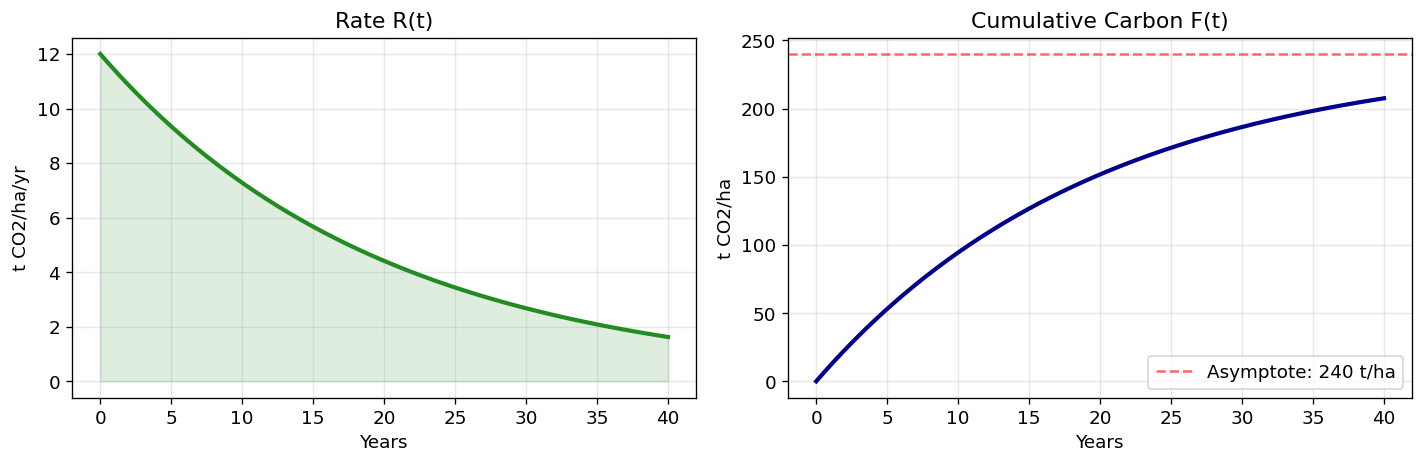

In [8]:
# B.2 — Plot cumulative carbon F(t)
t_vals = np.linspace(0, 40, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_vals, R(t_vals), "forestgreen", lw=2.5)
axes[0].fill_between(t_vals, R(t_vals), alpha=0.15, color="forestgreen")
axes[0].set_title("Rate R(t)")
axes[0].set_xlabel("Years")
axes[0].set_ylabel("t CO2/ha/yr")
axes[0].grid(alpha=0.3)

axes[1].plot(t_vals, F(t_vals), "darkblue", lw=2.5)
axes[1].axhline(240, color="red", ls="--", alpha=0.6, label="Asymptote: 240 t/ha")
axes[1].set_title("Cumulative Carbon F(t)")
axes[1].set_xlabel("Years")
axes[1].set_ylabel("t CO2/ha")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Rate-to-total checkpoint

Read the paired graphs as two different answers to one project question.

- Explain why $R(t)$ can decrease while $F(t)$ continues to increase.
- Use the shape of $F(t)$ to explain what the horizontal asymptote means for long-term carbon planning.
- Before calculating revenue, predict whether the first or last five years contribute more credits, then justify your prediction from the rate graph.

---
## Part C: Project Valuation (~20 min)

The project covers **500 ha** and carbon credits sell at **$25/tonne CO₂**.

**C.1** Calculate total carbon captured across the full 500 ha over 40 years.

**C.2** Calculate total revenue from selling carbon credits.

**C.3** At what year does the project capture half of its 40-year total?

In [9]:
# C.1 — Total carbon: 500 ha × F(40)
area_ha = 500
price_per_tonne = 25

F_40 = F(40)
total_carbon = area_ha * F_40
print(f"Carbon per hectare (0–40 yr): {F_40:.1f} t CO2/ha")
print(f"Total carbon (500 ha):        {total_carbon:,.0f} t CO2")

Carbon per hectare (0–40 yr): 207.5 t CO2/ha
Total carbon (500 ha):        103,760 t CO2


Revenue.

In [10]:
# C.2 — Revenue
total_revenue = total_carbon * price_per_tonne
print(f"Carbon credit revenue: ${total_revenue:,.0f}")

# C.3 — Year at which half the 40-year total is captured
half_target = F_40 / 2
# Solve F(t) = half_target → 240(1 - e^{-0.05t}) = half_target
# → e^{-0.05t} = 1 - half_target/240
# → t = -ln(1 - half_target/240) / 0.05
t_half = -np.log(1 - half_target / 240) / 0.05
print(f"\nHalf the 40-year total = {half_target:.1f} t CO2/ha")
print(f"Reached at year t = {t_half:.1f}")

# Verify
print(f"F({t_half:.1f}) = {F(t_half):.1f}  (check ≈ {half_target:.1f})")

Carbon credit revenue: $2,593,994

Half the 40-year total = 103.8 t CO2/ha
Reached at year t = 11.3
F(11.3) = 103.8  (check ≈ 103.8)


Annual revenue stream.

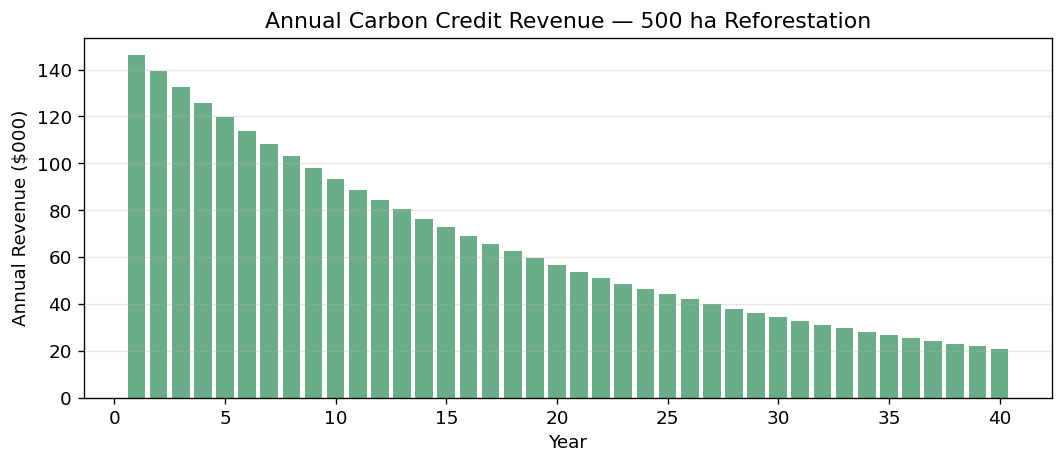

Year 1 revenue: $146,312
Year 40 revenue: $20,816
Total 40-year revenue: $2,593,994


In [11]:
# C.4 — Annual revenue stream
years = np.arange(1, 41)
annual_carbon_per_ha = np.array([F(t) - F(t-1) for t in years])
annual_revenue = annual_carbon_per_ha * area_ha * price_per_tonne

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(years, annual_revenue / 1e3, color="seagreen", alpha=0.7)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Revenue ($000)")
ax.set_title("Annual Carbon Credit Revenue — 500 ha Reforestation")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Year 1 revenue: ${annual_revenue[0]:,.0f}")
print(f"Year 40 revenue: ${annual_revenue[39]:,.0f}")
print(f"Total 40-year revenue: ${annual_revenue.sum():,.0f}")

✏️ **Group Discussion (2–3 sentences each):**

1. Why does the sequestration rate decrease over time? What biological process does this reflect?
2. The long-run limit of $F(t)$ is 240 t CO₂/ha. What does this mean for an infinite project?
3. Should landholders sell carbon credits annually or wait? What does the revenue profile suggest?

```
DISCUSSION:
...
```

---
## Part D: Symbolic Integration with SymPy (~10 min)

In Part B you found the antiderivative $F(t)$ **by hand**, using the rule $\int e^{kt}\,dt = \frac{1}{k}e^{kt} + C$. Python's **SymPy** library can find antiderivatives (and evaluate definite integrals) automatically — the same **symbolic computation** idea as `sp.diff()` in Weeks 4 and 5, just running in reverse. This is the standard tool you'll use for integration in Python throughout the rest of the unit.

Run the cell below to have SymPy integrate $R(t)$ symbolically, both indefinitely and over the full 0–40 year period, and compare to your by-hand results from Parts B and C.

In [12]:
# D.1 — Symbolic integration with SymPy
import sympy as sp

t_sym = sp.symbols('t')
R_expr = 12 * sp.exp(-0.05 * t_sym)

# Indefinite integral — SymPy's antiderivative (it omits the "+C"; you add that yourself)
F_indef = sp.integrate(R_expr, t_sym)
print(f"R(t) = {R_expr}")
print(f"∫R(t) dt = {F_indef} + C   ← matches the by-hand result from Part B (with C=240)")

# Definite integral over 0 to 40 years — total carbon captured per hectare
F_definite = sp.integrate(R_expr, (t_sym, 0, 40))
print(f"\n∫₀⁴⁰ R(t) dt = {F_definite} ≈ {float(F_definite):.2f} t CO2/ha   ← compare to F(40) in Part B/C")

R(t) = 12*exp(-0.05*t)
∫R(t) dt = -240.0*exp(-0.05*t) + C   ← matches the by-hand result from Part B (with C=240)

∫₀⁴⁰ R(t) dt = 207.519532023213 ≈ 207.52 t CO2/ha   ← compare to F(40) in Part B/C


**Why this matters:** `sp.integrate()` performs **symbolic integration** — it finds the antiderivative algebraically (the reverse of `sp.diff()`), rather than approximating an area numerically the way `numpy.trapz` did in A.2. Notice SymPy's indefinite integral **omits the constant of integration** — you still need to add $C$ and solve for it using an initial condition yourself, exactly as you did in Part B. For a definite integral (a specific numeric area, like the one above), $C$ cancels out automatically and SymPy gives you the exact answer directly.


---
## ✅ Submission Exercise — Batch 2 (due Tuesday 8 September, 11:59 pm)

**Submit via LMS. Covers Weeks 4–6 (limits, differentiation, integration).**

Work individually. Show all working. Write Python code where indicated.
Upload your **completed notebook (.ipynb)** to the LMS — do not submit screenshots.
        

In [17]:

# Fill in your details before submitting
student_name   = "Sara Eastough"
student_number = "25206803"
print(f"Submission by: {student_name}  |  Student #{student_number}")


Submission by: Sara Eastough  |  Student #25206803



---
### Q1 — Limits and Continuity (Week 4)

A population model uses:

$$P(t) = \frac{1000t}{t + 5}$$

**(a)** Evaluate $\lim_{t \to \infty} P(t)$. Show your working algebraically (divide numerator and denominator by $t$).
        


**Answer (a):**

lim P(t) = lim 100t/t/t+5/t
         = lim 1000/1+5
As t approaches infinity, 5/t approaches 0
lim P(t) = 1000/1+0 = 1000
Therefore the population limit = 1000
        


**(b)** Is $P(t)$ continuous for all $t \geq 0$? Justify briefly.
        


**Answer (b):**

t+5=0
So, t=-5 (-5+5=0)
Yes, it is continuous because t=-5 (point of discontinuity) is not greater than or equal to 0.

        


**(c)** Verify your limit numerically by evaluating $P(t)$ at $t = 100, 1000, 10000$.
        

In [14]:

# Q1c — numerical limit verification
import numpy as np

def P(t):
    return 1000*t / (t + 5)

# Evaluate at large t values — your code here
t_values = [100, 1000, 10000]

for t in t_values:
    result = P(t)
    print(f"t = {t:5d} ---> P(t) = {result:.4f}")


t =   100 ---> P(t) = 952.3810
t =  1000 ---> P(t) = 995.0249
t = 10000 ---> P(t) = 999.5002



---
### Q2 — Differentiation and Optimisation (Week 5)

A timber company's profit (thousands of dollars) as a function of harvest age $a$ (years) is:

$$\pi(a) = 80a - 2a^2 - 150 \quad \text{for } 5 \leq a \leq 30$$

**(a)** Find $\pi'(a)$ using the power rule. Show each step.
        


**Answer (a):**

Rule: d/da(c x a^n) = c x n x a^n-1

d/da(80a) = 80x1xa^0 = 80
d/da(-2a) = -2x2xa^1 = -4a
d/da(-150) = -150x0xa^-1 = 0

π'(a) = 80-4a
        


**(b)** Find the harvest age $a^*$ that maximises profit. Use the second derivative to confirm it is a maximum.
        


**Answer (b):**

80-4a=0
-4a=80
a* = 20
At 20 years maximum profit will be reached.
        


**(c)** Evaluate $\pi(a^*)$ and the boundary values $\pi(5)$ and $\pi(30)$ in Python.
        

In [18]:

# Q2c — profit at critical point and boundaries
import numpy as np

def pi_a(a):
    return 80*a - 2*a**2 - 150

a_star = 20
print(f"Profit at a* (20 years): {pi_a(a_star)} thousand dollars")
print(f"Profit at boundary a=5: {pi_a(5)} thousand dollars")
print(f"Profit at boundary a=30: {pi_a(30)} thousand dollars")

Profit at a* (20 years): 650 thousand dollars
Profit at boundary a=5: 200 thousand dollars
Profit at boundary a=30: 450 thousand dollars



**(d)** Interpret: what does $\pi'(a^*) = 0$ mean in harvesting terms?
        


**Answer (d):**

It means the timber company has reached the best harvest age for optimal profit maximisation.
        


---
### Q3 — Integration and Accumulation (Week 6)

A bushfire recovery site sequesters carbon at rate $R(t) = 8e^{-0.04t}$ tonnes CO₂/ha/yr.

**(a)** Find the antiderivative $F(t)$ with $F(0) = 0$. Show the rule you used.
        


**Answer (a):**

Rule: e^kt dt = 1/k e^kt + C

F(t) = 8/-0.04 e^-0.4t + C
     = -200e^-0.04t + C

0 = -200e^-0.04(0) + C
0 = -200 + C
C = 200
        


**(b)** Calculate the total carbon captured per hectare over 30 years. Give an exact expression and a decimal approximation.
        


**Answer (b):**

F(30) = -200e^-0.04(30) = -200e^-1.2
F(0) = -200e^-0.04(0) = -200

total carbon captured = F(30)-F(0)
= 139.76 tonnes CO2/ha
        


**(c)** Plot $R(t)$ for $t \in [0, 30]$, shade the area under the curve, and annotate with the integral value from (b).
        

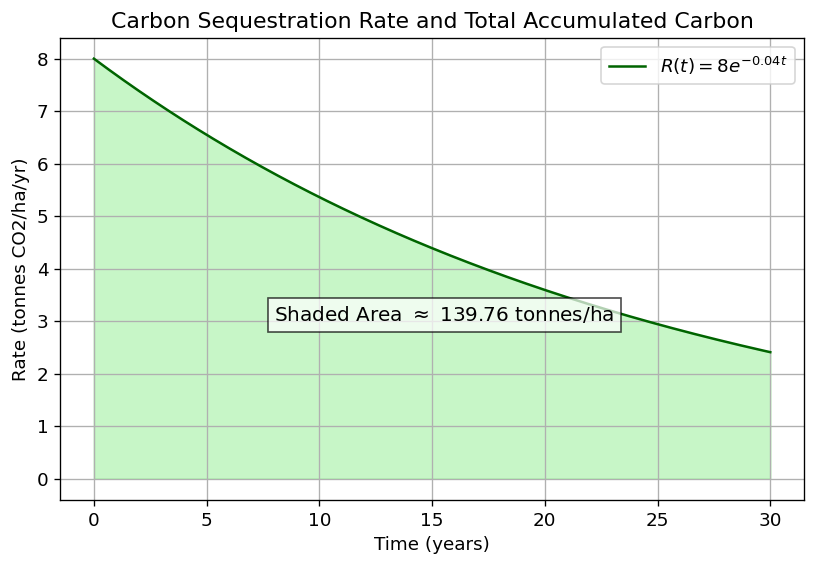

In [19]:

# Q3c — plot and shade
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

t = np.linspace(0, 30, 500)
R = 8 * np.exp(-0.04 * t)

plt.figure(figsize=(8, 5))
plt.plot(t, R, label='$R(t) = 8e^{-0.04t}$', color='darkgreen')
plt.fill_between(t, R, color='lightgreen', alpha=0.5)

plt.xlabel('Time (years)')
plt.ylabel('Rate (tonnes CO2/ha/yr)')
plt.title('Carbon Sequestration Rate and Total Accumulated Carbon')

plt.text(8, 3, 'Shaded Area $\\approx$ 139.76 tonnes/ha', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
plt.grid(True)
plt.legend()
plt.show()




**(d)** Carbon credits sell at $30/tonne and the site covers 250 ha. Calculate total project revenue over 30 years.
        


**Answer (d):**

Total site carbon = 139.76x250 = 34940
Total project revenue = 34940x30 = $1048200
        